<a href="https://colab.research.google.com/github/M4rck0/Procesamiento_Clasificacion_Datos/blob/main/Tarea_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerías
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
audios = {
    "Beber": "sonido_beber.mp3",
    "Freno": "sonido_freno.mp3",
    "Perro": "sonido_perro.mp3"
}


resultados = []

Beber


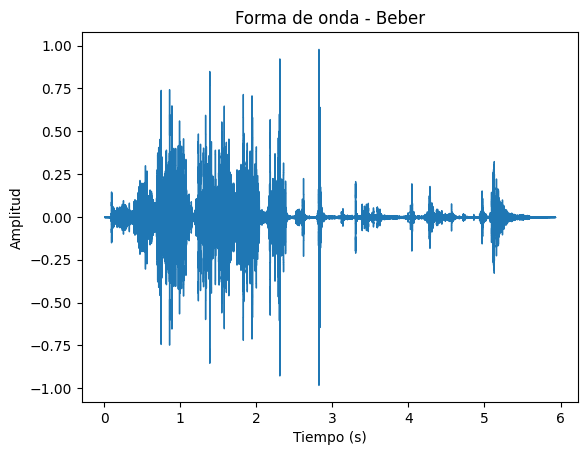

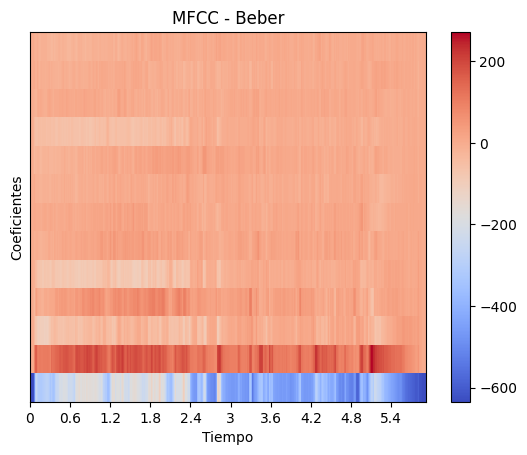

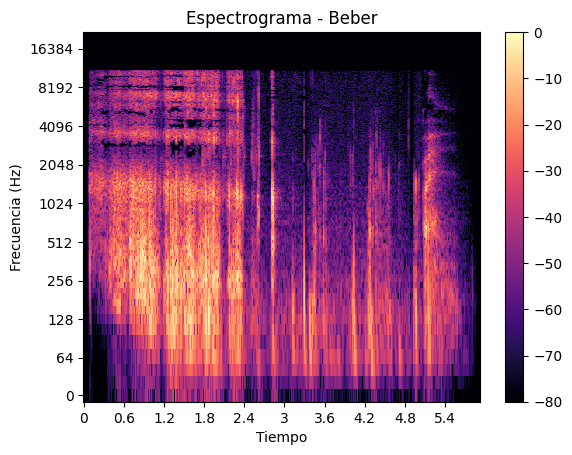

Freno


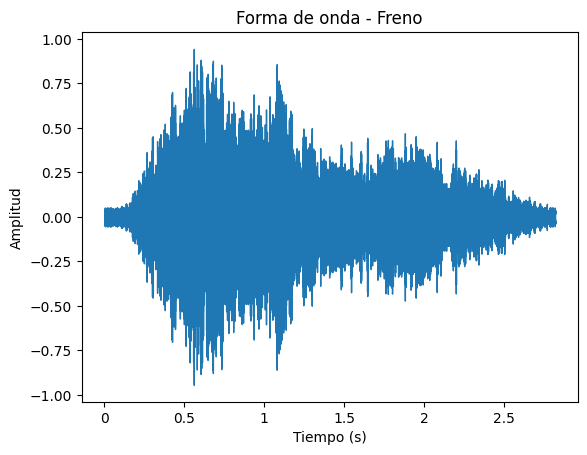

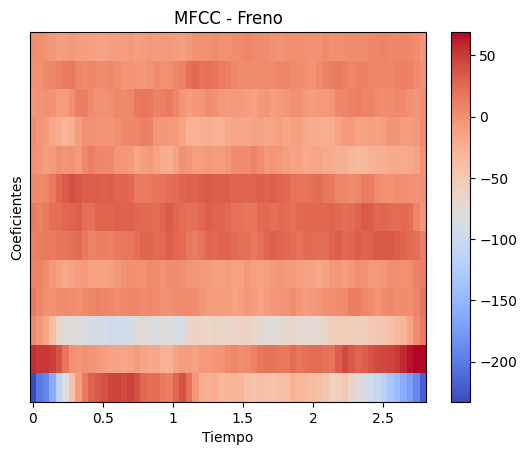

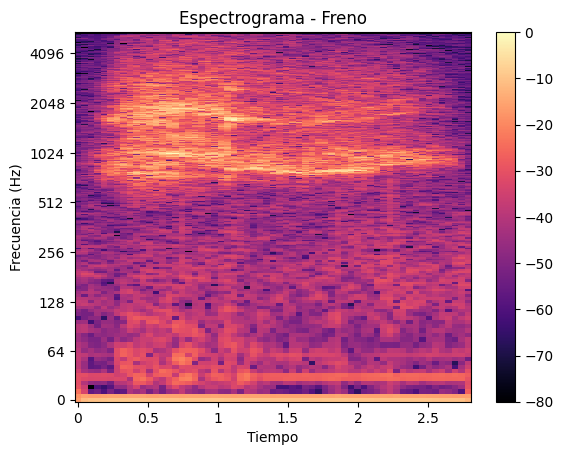

Perro


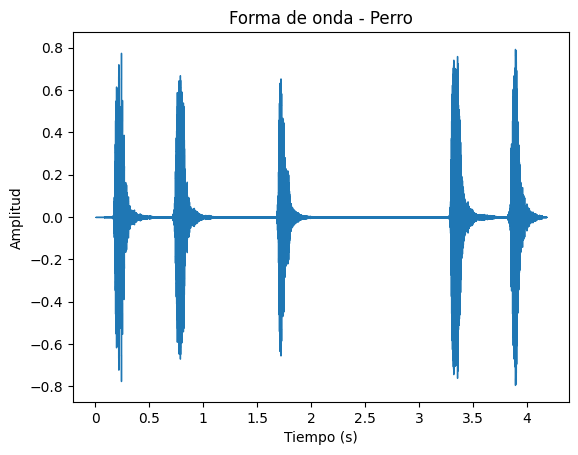

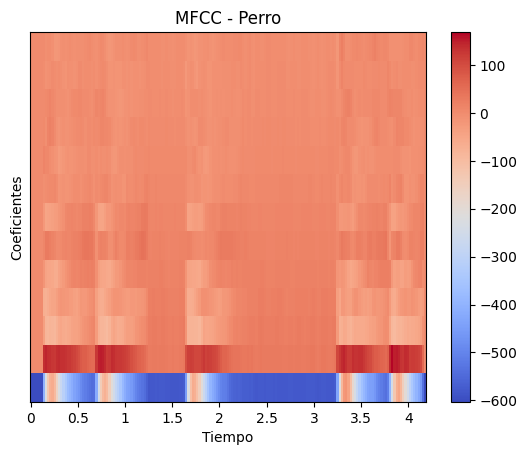

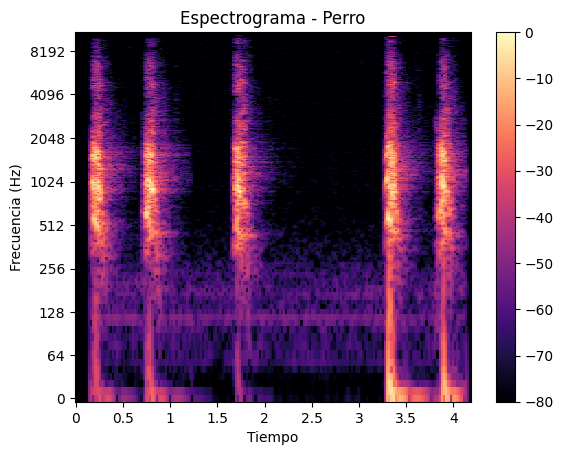

In [5]:
# Procesamiento

for nombre, archivo in audios.items():

    print(nombre)

    # Cargar audio
    y, sr = librosa.load(archivo, sr=None)

    # Duración
    duracion = librosa.get_duration(y=y, sr=sr)

    # Energía promedio
    energia = np.mean(y**2)

    # Forma de onda
    plt.figure()

    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Forma de onda - {nombre}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.show()

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    # promedio de cada coeficiente
    mfcc_promedio = np.mean(mfcc, axis=1)

    # Visualizar MFCC
    plt.figure()
    librosa.display.specshow(mfcc, sr=sr, x_axis="time")
    plt.colorbar()

    plt.title(f"MFCC - {nombre}")
    plt.ylabel("Coeficientes")
    plt.xlabel("Tiempo")
    plt.show()

    # Espectrograma
    S = librosa.stft(y)
    S_db = librosa.amplitude_to_db(abs(S), ref=np.max)

    plt.figure()
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log")
    plt.colorbar()

    plt.title(f"Espectrograma - {nombre}")
    plt.xlabel("Tiempo")
    plt.ylabel("Frecuencia (Hz)")
    plt.show()

    # Frecuencia dominante
    frecuencias = librosa.fft_frequencies(sr=sr)

    energia_frecuencia = np.sum(abs(S), axis=1)

    frecuencia_dominante = frecuencias[np.argmax(energia_frecuencia)]

    # Guardar resultados
    fila = {
        "Audio": nombre,
        "Duracion_seg": duracion,
        "Energia": energia,
        "Frecuencia_dominante_Hz": frecuencia_dominante
    }


    # Guardar MFCC
    for i, valor in enumerate(mfcc_promedio):
        fila[f"MFCC_{i+1}"] = valor


    resultados.append(fila)

In [6]:
tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

,Audio,Duracion_seg,Energia,Frecuencia_dominante_Hz,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,Beber,5.929229,0.003506,279.931641,-353.759888,137.264618,-16.795088,34.002243,-27.070036,15.774936,8.512694,0.695985,8.254182,-20.909252,4.625243,-0.184627,-1.258155
1,Freno,2.816780,0.027960,0.000000,-47.935215,15.353583,-62.445744,1.281323,-5.171243,23.170683,24.799356,20.658062,-9.710206,-10.751532,1.046268,6.914107,-1.547227
2,Perro,4.179592,0.005765,958.227539,-432.014282,77.309059,-19.647343,-9.345100,-0.954663,16.379196,2.168042,1.253015,-2.342572,-0.571783,-0.923550,-3.394894,-2.796070
3,Beber,5.929229,0.003506,279.931641,-353.759888,137.264618,-16.795088,34.002243,-27.070036,15.774936,8.512694,0.695985,8.254182,-20.909252,4.625243,-0.184627,-1.258155
4,Freno,2.816780,0.027960,0.000000,-47.935215,15.353583,-62.445744,1.281323,-5.171243,23.170683,24.799356,20.658062,-9.710206,-10.751532,1.046268,6.914107,-1.547227
5,Perro,4.179592,0.005765,958.227539,-432.014282,77.309059,-19.647343,-9.345100,-0.954663,16.379196,2.168042,1.253015,-2.342572,-0.571783,-0.923550,-3.394894,-2.796070
